# [기말 프로젝트] 임상 데이터를 활용한 심부전 환자의 생존 여부 예측
- 작성자: [설현우]
- 데이터 출처: Kaggle Heart Failure Clinical Records Dataset
- 프로젝트 목표: 본 프로젝트는 심부전 환자의 12가지 임상 데이터를 독립 변수로, 생존 여부를 종속 변수로 설정하여 이를 분류하는 머신러닝 모델을 구축함.
  변수 중요도 분석을 통해 생존/사망을 가르는 임상적 위험 요인을 도출하고 이를 시각화하여 데이터의 패턴을 규명

In [12]:
# 1. 데이터 분석 및 시각화 라이브러리
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. 머신러닝 데이터 분리 및 전처리
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 3. 머신러닝 분류 모델
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 4. 머신러닝 모델 평가 지표
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 5. 한글 폰트 깨짐 방지
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

In [13]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

In [14]:
#데이터 크기 확인
df.shape

(299, 13)

In [15]:
#상위 5개 확인
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [16]:
#결측치(빈칸) 확인
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [17]:
# 생존(0)/사망(1) 그룹 간 주요 수치 평균 비교
df.groupby('DEATH_EVENT')[['age', 'serum_sodium', 'platelets']].mean()

,age,serum_sodium,platelets
DEATH_EVENT,,,
0,58.761906,137.216749,266657.489901
1,65.215281,135.375000,256381.044792


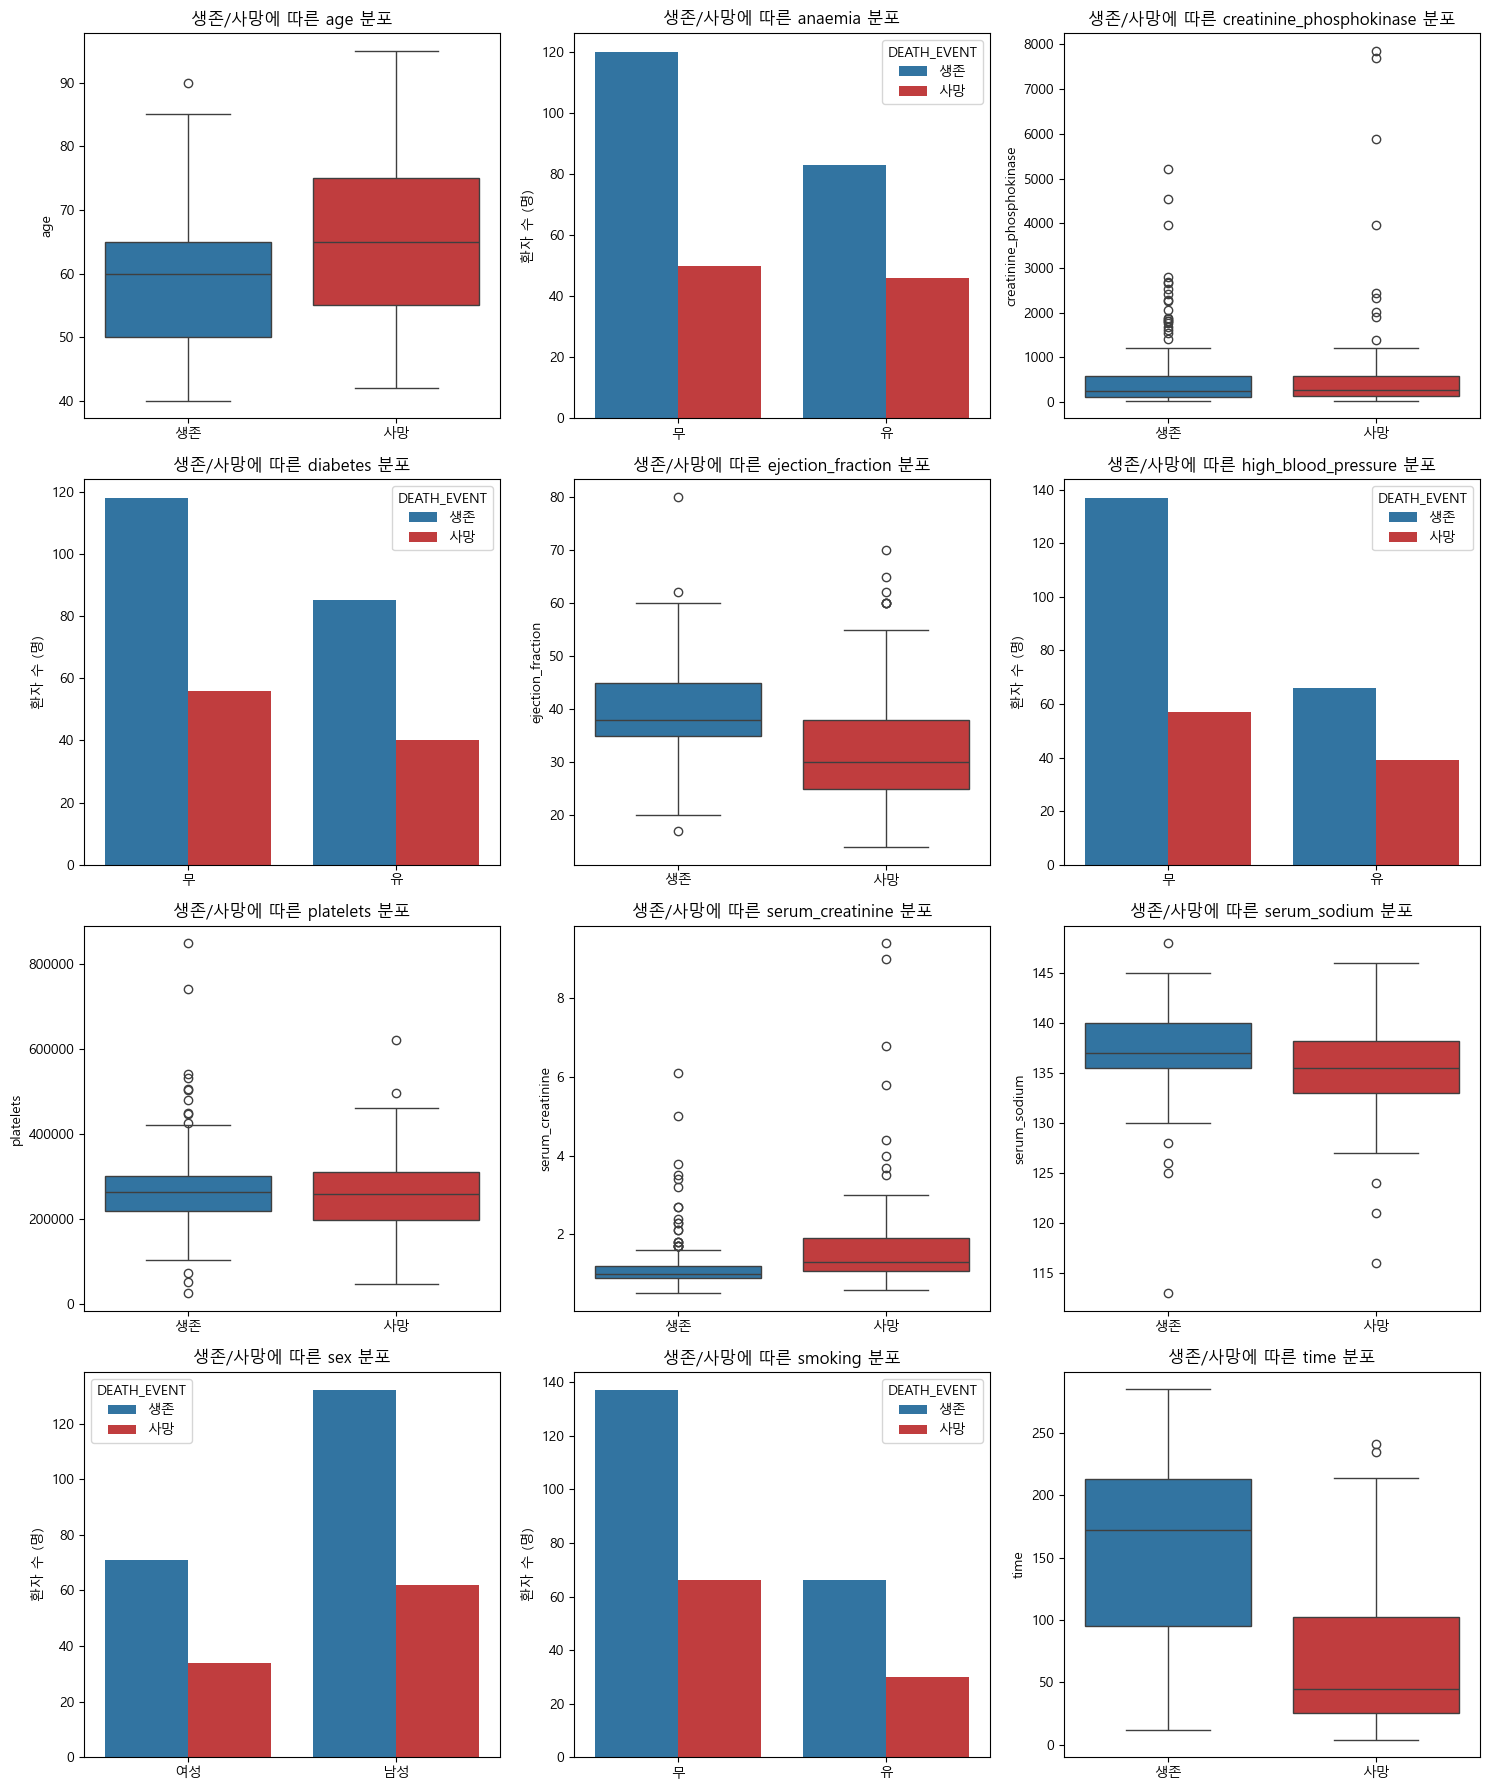

In [55]:
master_palette = {'생존': '#1f77b4', '사망': '#d62728'}

fig, axes = plt.subplots(4, 3, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(features):
    if col in categorical_features:
        sns.countplot(x=col, hue='DEATH_EVENT', data=df_plot, ax=axes[i], 
                      palette=master_palette, hue_order=['생존', '사망'])
        axes[i].set_ylabel('환자 수 (명)')
        axes[i].set_xticks([0, 1])
        
        if col == 'sex':
            axes[i].set_xticklabels(['여성', '남성'])
        else:
            axes[i].set_xticklabels(['무', '유'])
            
    else:
        sns.boxplot(x='DEATH_EVENT', y=col, data=df_plot, ax=axes[i], 
                    palette=master_palette, order=['생존', '사망'], legend=False,
                    hue='DEATH_EVENT')
        axes[i].set_ylabel(col)
    
    axes[i].set_title(f'생존/사망에 따른 {col} 분포', fontsize=12)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

In [56]:
# 1. 정답지(y)와 문제지(X) 분리
y = df['DEATH_EVENT']
X = df.drop('DEATH_EVENT', axis=1)

# 2. 학습용과 테스트 용데이터로 분리 (8:2 비율, 재현성 고정)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("[데이터 분리 결과]")
print(f"전체 데이터 개수: {len(X)}개")
print(f"학습용 데이터 개수: {len(X_train)}개")
print(f"테스트용 데이터 개수: {len(X_test)}개")
print("-" * 40)

# 3. 데이터 스케일링 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

[데이터 분리 결과]
전체 데이터 개수: 299개
학습용 데이터 개수: 239개
테스트용 데이터 개수: 60개
----------------------------------------


In [57]:
# 1. 분류 모델
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)

# 2. 모델 학습
knn.fit(X_train_scaled, y_train)
dt.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)

# 3. 테스트 데이터로 예측
knn_pred = knn.predict(X_test_scaled)
dt_pred = dt.predict(X_test_scaled)
rf_pred = rf.predict(X_test_scaled)

# 4. 채점하기 (단순 정확도만 먼저 확인)
print("[3가지 모델 정확도(Accuracy) 비교]")
print(f"1. KNN 정확도: {accuracy_score(y_test, knn_pred):.4f}")
print(f"2. 결정 트리 정확도: {accuracy_score(y_test, dt_pred):.4f}")
print(f"3. 랜덤 포레스트 정확도: {accuracy_score(y_test, rf_pred):.4f}")

[3가지 모델 정확도(Accuracy) 비교]
1. KNN 정확도: 0.6833
2. 결정 트리 정확도: 0.6333
3. 랜덤 포레스트 정확도: 0.7500


,Accuracy(정확도),Precision(정밀도),Recall(재현율),F1-score
KNN,0.683333,0.875000,0.28,0.424242
Decision Tree,0.633333,0.578947,0.44,0.500000
Random Forest,0.750000,0.857143,0.48,0.615385


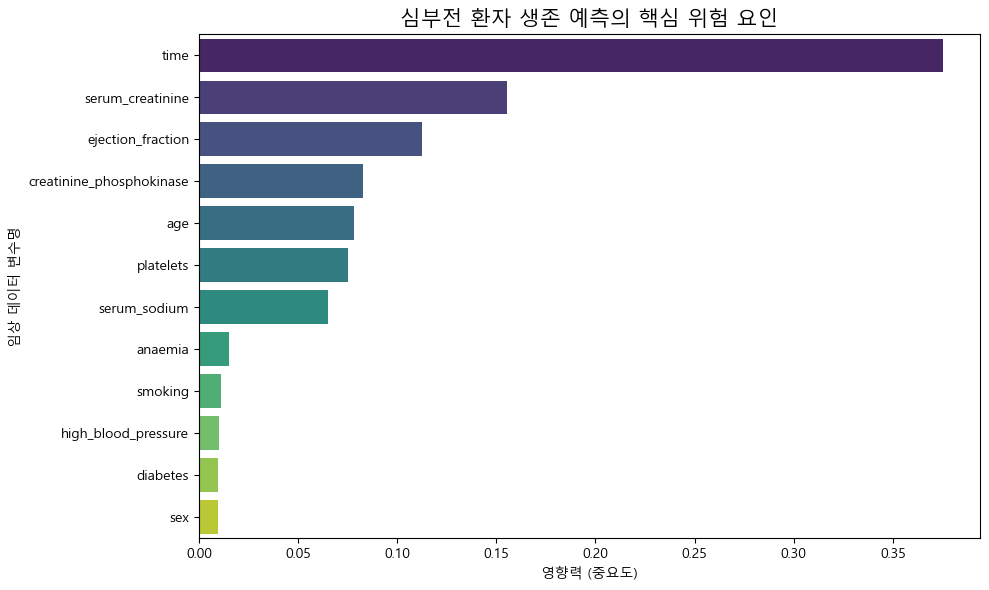

In [58]:
#3가지 모델을 평가하고 가장 우수한 AI가 뽑은 요인을 시각화합니다

# 1. 3가지 모델의 심층 평가 지표를 한눈에 볼 수 있도록 표로 만들기
def get_scores(y_test, pred):
    acc = accuracy_score(y_test, pred)
    pre = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    return [acc, pre, rec, f1]

# 각 모델별 점수 계산
score_df = pd.DataFrame([get_scores(y_test, knn_pred), 
                         get_scores(y_test, dt_pred), 
                         get_scores(y_test, rf_pred)],
                        columns=['Accuracy(정확도)', 'Precision(정밀도)', 'Recall(재현율)', 'F1-score'],
                        index=['KNN', 'Decision Tree', 'Random Forest'])
display(score_df)


# 2. 어떤 요인이 환자의 생존에 가장 치명적이었을까? (변수 중요도 시각화)
importances = rf.feature_importances_

# 변수 이름과 중요도를 짝지어 표로 만들고, 내림차순으로 정렬
feature_df = pd.DataFrame({'변수명': X.columns, '중요도': importances})
feature_df = feature_df.sort_values(by='중요도', ascending=False)

# 가로 막대그래프로 시각화 
plt.figure(figsize=(10, 6))

sns.barplot(x='중요도', y='변수명', data=feature_df, palette='viridis', hue='변수명', legend=False)

plt.title('심부전 환자 생존 예측의 핵심 위험 요인', fontsize=15)
plt.xlabel('영향력 (중요도)')
plt.ylabel('임상 데이터 변수명')
plt.tight_layout()
plt.show()

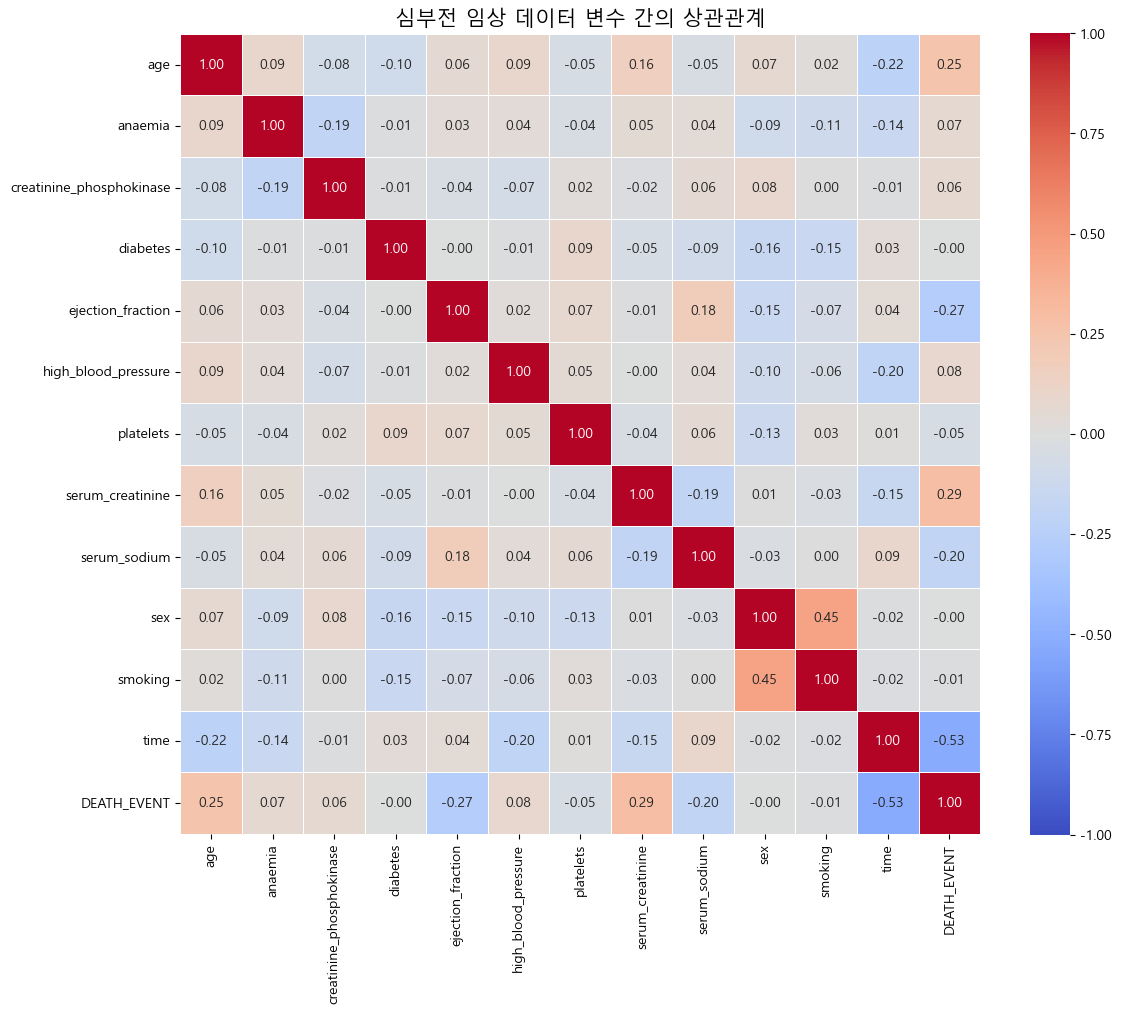

In [59]:
# 데이터 전체의 상관관계 히트맵 시각화
plt.figure(figsize=(12, 10))

# 연속형/숫자형 데이터만 뽑아서 상관계수 계산
corr = df.corr()

# 히트맵 그리기 (파란색~빨간색으로 관계의 강도를 표현)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, 
            square=True, linewidths=.5, annot_kws={"size": 10})

plt.title('심부전 임상 데이터 변수 간의 상관관계', fontsize=15)
plt.tight_layout()
plt.show()

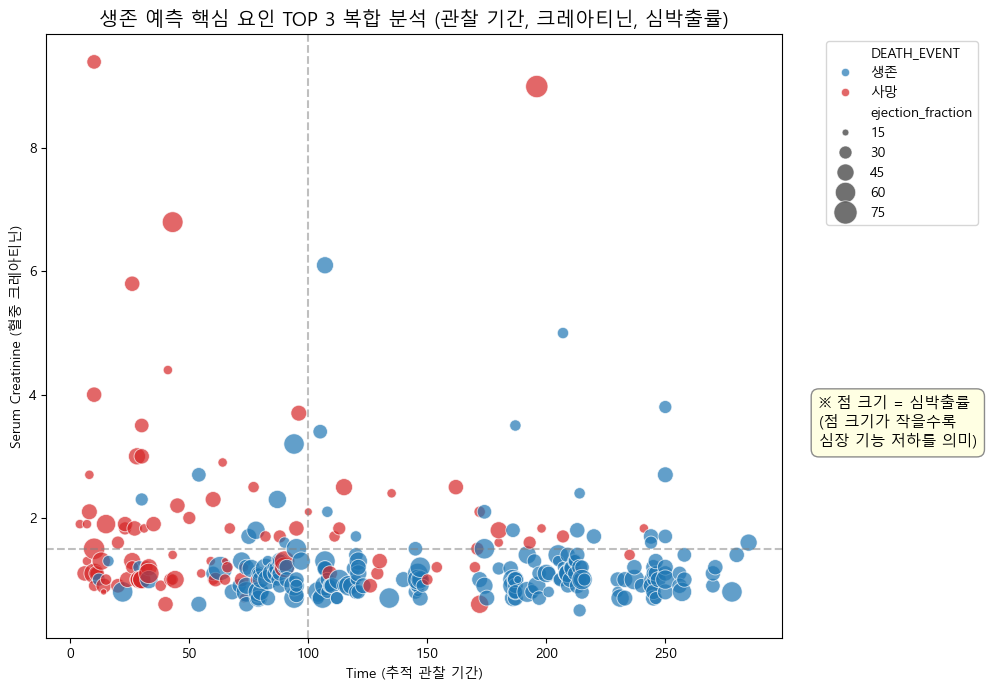

In [63]:
# TOP 3 핵심 요인 복합 분석 (버블 차트)
plt.figure(figsize=(10, 7))

sns.scatterplot(x='time', y='serum_creatinine', size='ejection_fraction',
                hue='DEATH_EVENT', hue_order=['생존', '사망'], data=df_plot, 
                palette=master_palette, sizes=(20, 300), alpha=0.7)

plt.title('생존 예측 핵심 요인 TOP 3 복합 분석 (관찰 기간, 크레아티닌, 심박출률)', fontsize=14)
plt.xlabel('Time (추적 관찰 기간)')
plt.ylabel('Serum Creatinine (혈중 크레아티닌)')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.text(1.05, 0.4, '※ 점 크기 = 심박출률\n(점 크기가 작을수록\n심장 기능 저하를 의미)', 
         transform=plt.gca().transAxes, fontsize=11, ha='left', va='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor='gray', alpha=0.9))

plt.axhline(1.5, color='gray', linestyle='--', alpha=0.5) 
plt.axvline(100, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()